# import

In [ ]:
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import ne_chunk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

import string

import matplotlib.pyplot as plt

!pip install spacy
!python -m spacy download en_core_web_lg
import spacy

!pip install afinn
from afinn import Afinn

!pip install -U scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer

!pip install adjustText
from nltk import ngrams
from adjustText import adjust_text

import numpy as np

import seaborn as sns


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# I Data Cleaning & Preprocessing

In [ ]:
# Load stopwords
stopwords_set = set(stopwords.words('english'))
additional_stopwords = ['im', 'dont', 'na', 'aint', 'youre', 'em', 'Cause', 'cause', 'theres', 'shes', 'hes', 'gon']
stopwords_set.update(additional_stopwords)

# Read lyrics file
with open('eminem_lyrics.txt', 'r') as file:
    content = file.read()

songs = content.split('\n\n\n')

data = {'Title': [], 'Lyrics': []}
lyrics_words = []

for song in songs:
    lines = song.split('\n')
    title = lines[0].strip()
    lyrics = '\n'.join([lyric.strip() for lyric in lines[1:] if lyric.strip()])

    lyrics = re.sub(r'[^\w\s]', '', lyrics)  # Remove punctuation

    words = word_tokenize(lyrics)

    filtered_words = [word for word in words if word.lower() not in stopwords_set]

    # Censor specific words
    censored_words = []
    for word in filtered_words:
        if word.lower() == 'fuck':
            censored_words.append('f-word')
        elif word.lower() == 'bitch':
            censored_words.append('b-word')
        elif word.lower() == 'fuckin':
            censored_words.append('f-word2')
        elif word.lower() == 'shit':
            censored_words.append('s-word')
        elif word.lower() == 'fucking':
             censored_words.append('f-word3')
        else:
            censored_words.append(word)

    lyrics_words.extend(censored_words)

    data['Title'].append(title)
    data['Lyrics'].append(lyrics)

# Creating a DataFrame

df = pd.DataFrame(data)

df_content = pd.DataFrame({"word": lyrics_words})

word_counts = df_content['word'].value_counts().reset_index()
word_counts.columns = ['Word', 'Count']

top_words = word_counts.head(15)

print(top_words)


      Word  Count
0     like   1328
1      get    820
2      got    740
3     know    610
4     back    599
5   s-word    591
6   f-word    547
7       go    487
8      say    457
9      one    435
10   never    415
11     see    388
12    time    341
13  b-word    332
14   think    328


In [ ]:
# A list with all the titles
titles = df['Title'].tolist()
print(titles)

['2.0 Boys', '25 to Life', '3AM', '3 Verses', '313', '50 Ways', '8 Mile', 'Alfred (Outro)', 'Almost Famous', 'Almost Haunted', 'Amityville', 'Any Man', 'Arose', 'As The World Turns', 'Ass Like That', 'Asshole', 'Baby', 'Backstabber', 'Bad Guy', 'Bad Guys Always Die', 'Bad Husband', 'Bad Influence', 'Bad Meets Evil', 'Bagpipes From Baghdad', 'Beautiful', 'Beautiful Pain', 'Believe', 'Berzerk', 'Bet Shady 2.0 Cypher', 'Big Weenie', 'Bitch Please II', 'Biterphobia', 'Boy Meets Girl', 'Brain Damage', 'Brainless', 'Buffalo Bill', 'Bump Heads', 'Business', 'Careful What You Wish For', 'Castle', 'Chloraseptic', 'Cinderella Man', 'Cleanin Out My Closet', 'Cocaine', 'Cold Wind Blows', 'Constantly Armed', 'Crack A Bottle', "Crackers 'n Cheese", 'Crazy In Love', 'Criminal', 'Cure', 'Curtains Close (Skit)', 'Darkness', 'Deja Vu', 'Desperation', 'Despicable', 'Diamond Style', 'Difficult', "Don't Front", 'Dr. West (Skit)', 'Drips', 'Drones', "Drop The Bomb On 'em", 'Drug Ballad', 'Echo', 'Elevator',

# II tf-idf

In [ ]:
def calculate_tfidf(corpus):
    vectorizer = TfidfVectorizer(min_df=50, max_df=90) #70 120
    tfidf_matrix = vectorizer.fit_transform(corpus)
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = tfidf_matrix.toarray()
    return tfidf_scores, feature_names

corpus = df['Lyrics'].tolist()
tfidf_scores, feature_names = calculate_tfidf(corpus)

for i, title in enumerate(df['Title']):
    print(f"TF-IDF scores for '{title}':")
    for j, feature in enumerate(feature_names):
        print(f"{feature}: {tfidf_scores[i][j]}")
    print()


Datele de ieșire de afișat au fost trunchiate la ultimele 5000 linii.
run: 0.0
same: 0.0
shady: 0.0
she: 0.2762855368307268
should: 0.05911719298124925
show: 0.12627473122699787
sick: 0.06039181985585915
since: 0.0
something: 0.06462258015499181
spit: 0.0
stop: 0.0
tell: 0.05033905936028683
than: 0.05064045448707136
thing: 0.0
thought: 0.0
throw: 0.0
told: 0.0
try: 0.05094525528057543
tryna: 0.06172967667189563
turn: 0.0
two: 0.10128090897414271
us: 0.1625974349261721
used: 0.06219079188708105
wait: 0.0
walk: 0.0
well: 0.05033905936028683
went: 0.0
whats: 0.187979780694415
where: 0.0
while: 0.0
whole: 0.0
will: 0.0
wont: 0.0
world: 0.0
would: 0.10128090897414271
ya: 0.0
yo: 0.0
youll: 0.12255262332048937

TF-IDF scores for 'Stay Wide Awake':
after: 0.0
always: 0.0
am: 0.0
another: 0.19855268790511785
any: 0.0
around: 0.03292592382336601
ass: 0.0
away: 0.11324387947152921
baby: 0.0
bad: 0.0
beat: 0.0
before: 0.03774795982384307
big: 0.0
bout: 0.040625302067134675
call: 0.0
crazy: 0.0419

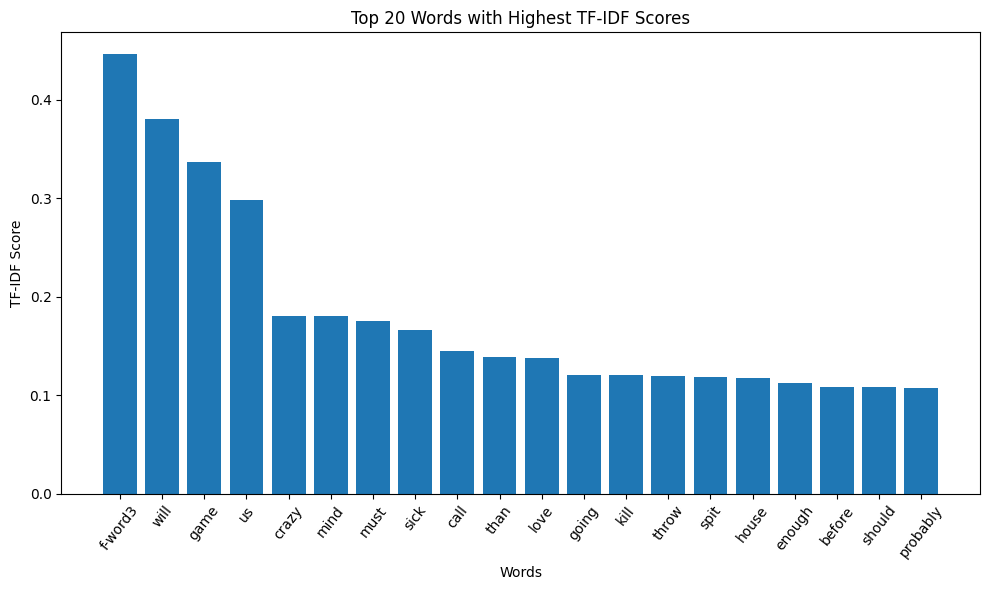

In [ ]:
# Sort the words based on TF-IDF scores
sorted_words = sorted(zip(feature_names, tfidf_scores[0]), key=lambda x: x[1], reverse=True)

# Extract the top 20 words and scores
top_words = sorted_words[:20]
words, scores = zip(*top_words)

# Replace "fucking" with "f-word3", "f-word2" with "f-word2", and "bitch" with "b-word" in the words list
words = ['f-word3' if word == 'fucking' else 'f-word2' if word == 'f-word2' else 'b-word' if word == 'bitch' else word for word in words]
filtered_words = [word for word in words if word.lower() not in stopwords_set]

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(words, scores)
plt.xticks(rotation=52)
plt.xlabel('Words')
plt.ylabel('TF-IDF Score')
plt.title("Top 20 Words with Highest TF-IDF Scores")
plt.tight_layout()
plt.show()


# III N-grams

6 [0.02577361 0.12553597]
7 [0.43094295 0.47617696]


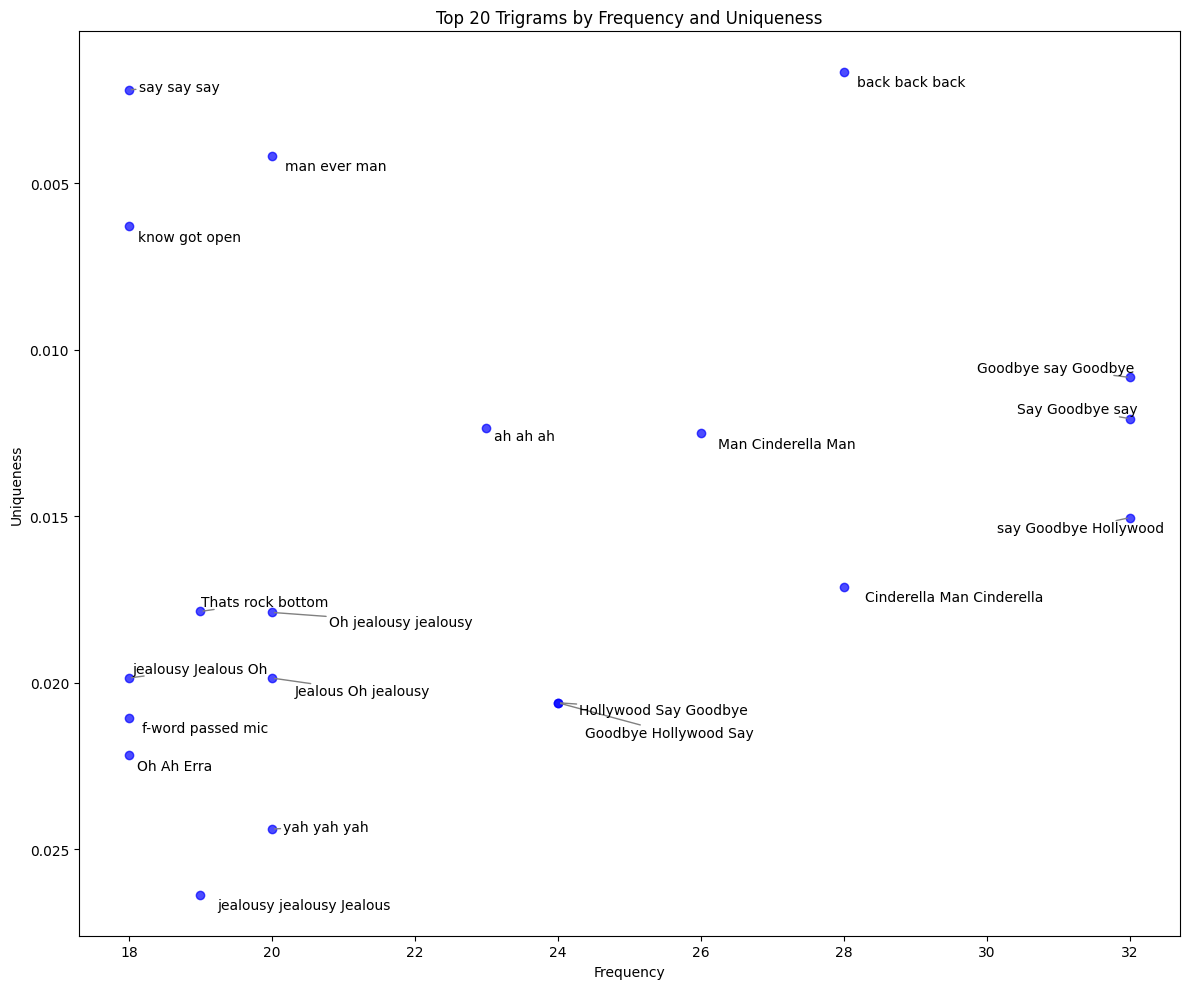

In [ ]:
n = 3 # A number for N-grams

lyrics_string = ' '.join(lyrics_words)

words = nltk.word_tokenize(lyrics_string)

# Calculate word frequencies and word uniqueness
word_counts = nltk.FreqDist(words)
word_uniqueness = {word: 1 / count for word, count in word_counts.items()}

ngram_counts = nltk.FreqDist(ngrams(words, n))

# Get the most common trigrams with their frequencies and uniqueness
top_ngrams = ngram_counts.most_common(20)
trigrams = [' '.join(trigram) for trigram, count in top_ngrams]
frequencies = [count for trigram, count in top_ngrams]
uniqueness = [sum(word_uniqueness[word] for word in trigram) / n for trigram, count in top_ngrams]

# Create a scatter plot of trigrams based on frequency and uniqueness
plt.figure(figsize=(12, 10))
plt.scatter(frequencies, uniqueness, c='blue', alpha=0.7)
plt.xlabel('Frequency')
plt.ylabel('Uniqueness')
plt.title('Top 20 Trigrams by Frequency and Uniqueness')

# Add trigrams to the right side of the scatter plot with adjusted positions
texts = []
for i, txt in enumerate(trigrams):
    texts.append(plt.text(frequencies[i], uniqueness[i], txt))

# Adjust the positions of the trigram annotations to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))

plt.gca().invert_yaxis()
plt.tight_layout()

# Show the plot
plt.show()


# IV PoS tags

In [ ]:
pos_tags = nltk.pos_tag(words)
pos_tags

[('Ryans', 'NNS'),
 ('homicidal', 'VBP'),
 ('misfit', 'JJ'),
 ('write', 'JJ'),
 ('solution', 'NN'),
 ('biophysics', 'NNS'),
 ('side', 'VBP'),
 ('cliff', 'JJ'),
 ('hieroglyphics', 'NNS'),
 ('admission', 'NN'),
 ('violent', 'JJ'),
 ('psychotic', 'JJ'),
 ('wit', 'NN'),
 ('Devour', 'NNP'),
 ('polish', 'JJ'),
 ('politics', 'NNS'),
 ('way', 'NN'),
 ('higher', 'JJR'),
 ('Eiffel', 'NNP'),
 ('Tower', 'NNP'),
 ('tip', 'NN'),
 ('like', 'IN'),
 ('writing', 'VBG'),
 ('stick', 'JJ'),
 ('pencil', 'NN'),
 ('ass', 'NN'),
 ('write', 'JJ'),
 ('s-word', 'JJ'),
 ('pause', 'NN'),
 ('inhaling', 'VBG'),
 ('hella', 'NN'),
 ('kush', 'VB'),
 ('Us', 'NNP'),
 ('Yelawolf', 'NNP'),
 ('like', 'IN'),
 ('heavy', 'JJ'),
 ('foot', 'NN'),
 ('gas', 'NN'),
 ('pedal', 'NN'),
 ('push', 'NN'),
 ('Felons', 'NNP'),
 ('crooks', 'VBZ'),
 ('going', 'VBG'),
 ('doortodoor', 'NNS'),
 ('Like', 'IN'),
 ('selling', 'VBG'),
 ('books', 'NNS'),
 ('Dolly', 'NNP'),
 ('Parton', 'NNP'),
 ('style', 'NN'),
 ('melons', 'NNS'),
 ('mushed', 'VBD'),


In [ ]:
pos_df = pd.DataFrame(pos_tags, columns=['Word', 'PoS'])
pos_df.head()

,Word,PoS
0,Ryans,NNS
1,homicidal,VBP
2,misfit,JJ
3,write,JJ
4,solution,NN


In [ ]:
# Count the frequency of each PoS tag and convert it to a dataframe
counts_df = pos_df.groupby('PoS').size().reset_index(name='Count')
counts_df

,PoS,Count
0,$,6
1,'',1
2,CC,75
3,CD,1110
4,DT,294
5,EX,1
6,FW,125
7,IN,2385
8,JJ,12744
9,JJR,272


In [ ]:
excluded_words = ['Ill', 'gon', 'Thats', 'Oh', 'Yeah']  # List of words to exclude

noun_df = pos_df[pos_df['PoS'].isin(['NN', 'NNP'])]  # Filter to keep only nouns

# Exclude specific words from the DataFrame
noun_df = noun_df[~noun_df['Word'].isin(excluded_words)]

noun_counts = noun_df['Word'].value_counts().head(10)  # Count the occurrences of words
print(noun_counts)


Word
time      341
man       256
way       240
s-word    182
Shady     174
life      169
f-word    168
world     167
day       167
get       165
Name: count, dtype: int64


In [ ]:
print(noun_df.head())
print(noun_df.columns)

         Word  PoS
4    solution   NN
9   admission   NN
12        wit   NN
13     Devour  NNP
16        way   NN
Index(['Word', 'PoS'], dtype='object')


/tmp/ipython-input-4206573420.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=noun_counts, y=noun_counts.index, ax=axes[0, 0], palette='Blues_r')
/tmp/ipython-input-4206573420.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=verb_counts, y=verb_counts.index, ax=axes[0, 1], palette='Greens_r')
/tmp/ipython-input-4206573420.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=adj_counts, y=adj_counts.index, ax=axes[1, 0], palette='Reds_r')
/tmp/ipython-input-4206573420.py:17: FutureWarning: 

Passing `palette` without assigning 

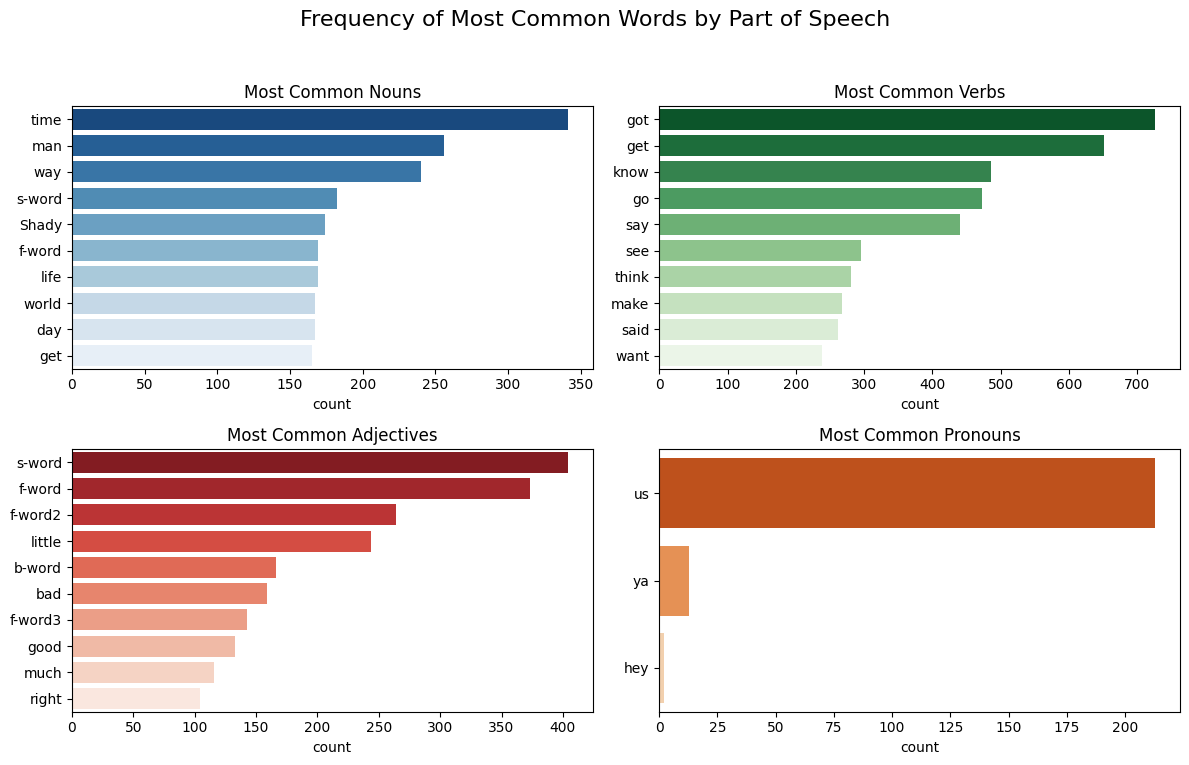

In [ ]:
excluded_nouns = ['Ill', 'gon', 'Thats', 'Oh', 'Yeah', 'thats']  # List of words to exclude for nouns
excluded_verbs = []  # List of words to exclude for verbs
excluded_adjectives = ['cant', 'ta']  # List of words to exclude for adjectives
excluded_pronouns = ['yeah', 'oh', 'gather', 'hang', 'tore', 'butcher', 'mother', 'ho', 'shelf', 'halfbrother', 'hell']  # List of words to exclude for pronouns

# Count occurrences of each PoS after excluding specific words
noun_counts = pos_df.loc[pos_df['PoS'].str.startswith('N') & ~pos_df['Word'].isin(excluded_nouns), 'Word'].value_counts().head(10)
verb_counts = pos_df.loc[pos_df['PoS'].str.startswith('V') & ~pos_df['Word'].isin(excluded_verbs), 'Word'].value_counts().head(10)
adj_counts = pos_df.loc[pos_df['PoS'].str.startswith('JJ') & ~pos_df['Word'].isin(excluded_adjectives), 'Word'].value_counts().head(10)
pronoun_counts = pos_df.loc[pos_df['PoS'].str.startswith('PR') & ~pos_df['Word'].isin(excluded_pronouns), 'Word'].value_counts().head(3)

# Rest of the code remains the same
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.barplot(x=noun_counts, y=noun_counts.index, ax=axes[0, 0], palette='Blues_r')
sns.barplot(x=verb_counts, y=verb_counts.index, ax=axes[0, 1], palette='Greens_r')
sns.barplot(x=adj_counts, y=adj_counts.index, ax=axes[1, 0], palette='Reds_r')
sns.barplot(x=pronoun_counts, y=pronoun_counts.index, ax=axes[1, 1], palette='Oranges_r')

# Set plot titles
axes[0, 0].set_title('Most Common Nouns')
axes[0, 1].set_title('Most Common Verbs')
axes[1, 0].set_title('Most Common Adjectives')
axes[1, 1].set_title('Most Common Pronouns')

# Set y-axis labels to be more readable
for ax in axes.flat:
    ax.set_ylabel('')

# Set overall plot title and adjust spacing
plt.suptitle('Frequency of Most Common Words by Part of Speech', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
noun_counts = pos_df.loc[pos_df['PoS'].str.startswith('N') & ~pos_df['Word'].isin(excluded_nouns), 'Word'].value_counts().head(10)
verb_counts = pos_df.loc[pos_df['PoS'].str.startswith('V') & ~pos_df['Word'].isin(excluded_verbs), 'Word'].value_counts().head(10)
adj_counts = pos_df.loc[pos_df['PoS'].str.startswith('JJ') & ~pos_df['Word'].isin(excluded_adjectives), 'Word'].value_counts().head(10)
pronoun_counts = pos_df.loc[pos_df['PoS'].str.startswith('PR') & ~pos_df['Word'].isin(excluded_pronouns), 'Word'].value_counts().head(5)

print(noun_counts)
print(verb_counts)
print(adj_counts)
print(pronoun_counts)


Word
time      341
man       256
way       240
s-word    182
Shady     174
f-word    169
life      169
world     167
day       167
get       165
Name: count, dtype: int64
Word
got      726
get      651
know     486
go       472
say      440
see      296
think    281
make     267
said     262
want     238
Name: count, dtype: int64
Word
s-word     404
f-word     373
f-word2    264
little     244
b-word     166
bad        159
f-word3    143
good       133
much       116
right      104
Name: count, dtype: int64
Word
us      213
ya       13
hey       2
yo        1
hurt      1
Name: count, dtype: int64


# V NER (Named Entity Recognition)

In [ ]:
nlp = spacy.load('en_core_web_lg')

In [ ]:
doc = nlp(lyrics)

for ent in doc.ents:
    print(ent.text, ent.label_)

The days DATE
Proof PERSON
Dres Phantom PERSON
Halloween DATE
The days DATE
Doody PERSON
Imma ORG
2 CARDINAL
tonight TIME
Mike Tyson PERSON
Naw Doody PERSON
one more day DATE


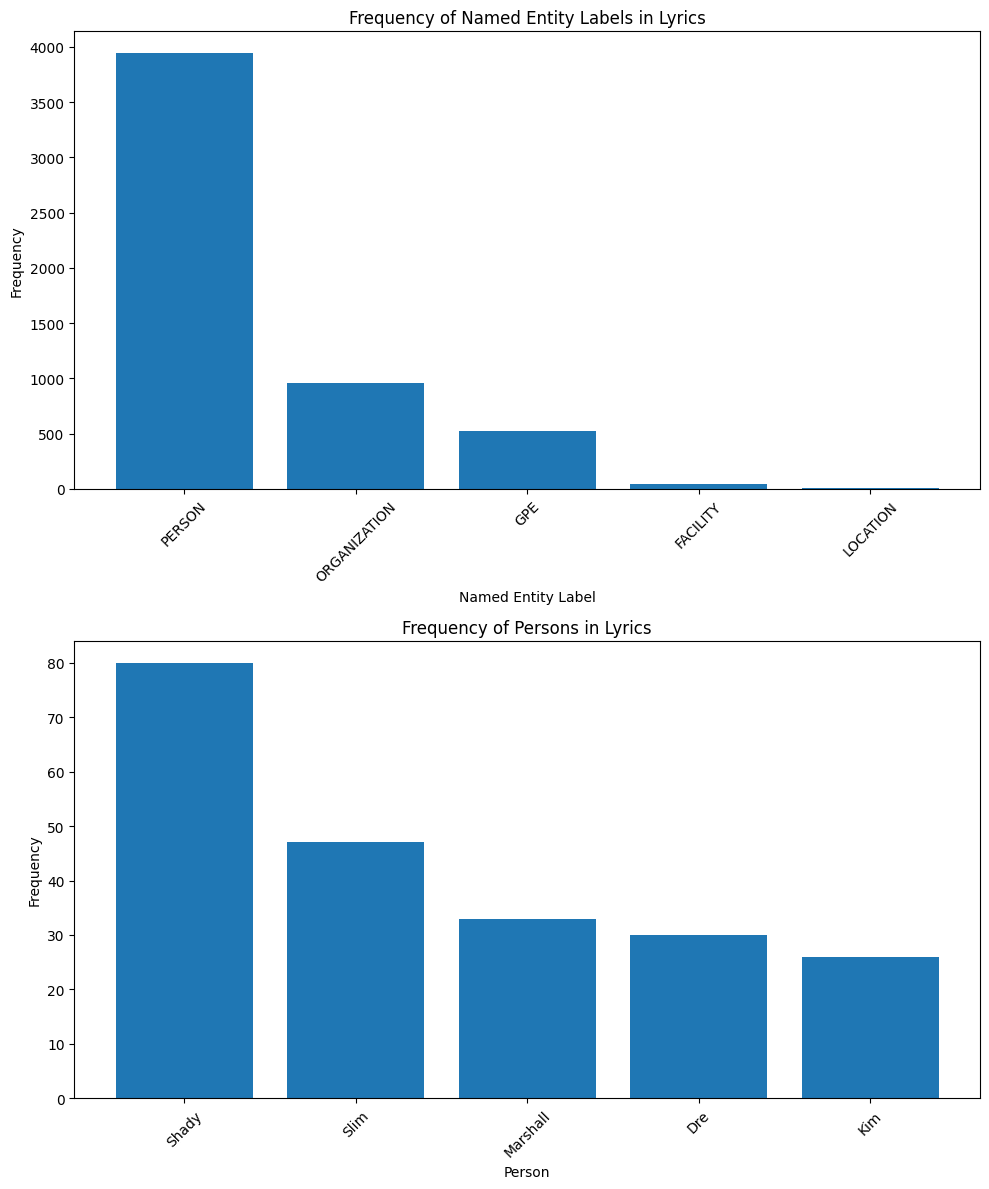

In [ ]:
# List of words to remove
words_to_remove = ['Im', 'Ill', 'Cause', 'Dont', 'Ive', 'Ima', 'Fuck', 'Yeah', 'Goodbye', 'Bitch', 'Hollywood']

# Perform named entity recognition on the lyrics
entities = []
persons = []

for lyric in df['Lyrics']:
    tokens = nltk.word_tokenize(lyric)
    tagged = nltk.pos_tag(tokens)
    named_entities = ne_chunk(tagged, binary=False)

    entities.extend([chunk.label() for chunk in named_entities if hasattr(chunk, 'label')])
    persons.extend([chunk[0][0] for chunk in named_entities if isinstance(chunk, nltk.tree.Tree) and chunk.label() == 'PERSON' and chunk[0][0] not in words_to_remove])

# Remove the specified words from the list of entities
entities = [entity for entity in entities if entity not in words_to_remove]

# Count the occurrences of each named entity label
entity_counts = nltk.FreqDist(entities)
person_counts = nltk.FreqDist(persons)

# Get the top 10 most common named entity labels
top_labels = entity_counts.most_common(5)
top_persons = person_counts.most_common(5)

# Extract the labels and frequencies
labels = [label for label, count in top_labels]
frequencies = [count for label, count in top_labels]

# Extract the persons and frequencies
persons = [person for person, count in top_persons]
person_frequencies = [count for person, count in top_persons]

# Create two separate bar plots
fig, axs = plt.subplots(2, 1, figsize=(10, 12))

# Plot for named entity labels
axs[0].bar(labels, frequencies)
axs[0].set_xlabel('Named Entity Label')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Frequency of Named Entity Labels in Lyrics')
axs[0].tick_params(axis='x', rotation=45)

# Plot for persons
axs[1].bar(persons, person_frequencies)
axs[1].set_xlabel('Person')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Frequency of Persons in Lyrics')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


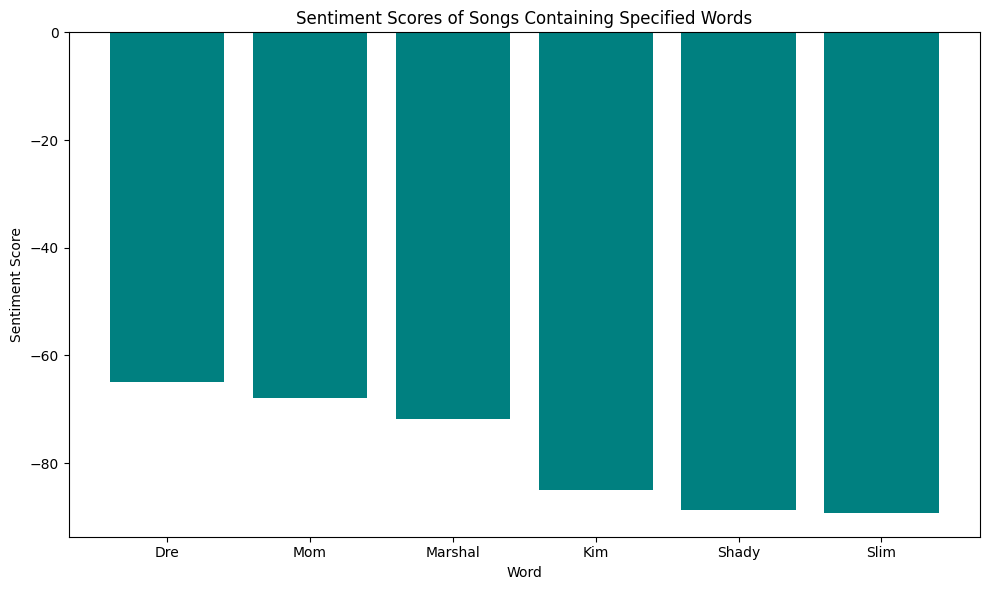

In [ ]:
from afinn import Afinn

# Create an instance of the Afinn class
afinn = Afinn()

# Assuming your lyrics are in a column called 'Lyrics'
df['SentimentScore'] = df['Lyrics'].apply(lambda x: afinn.score(x))

# Words to check for sentiment
words_to_check = ['Kim', 'Dre', 'Shady', 'Marshal', 'Mom', 'Slim']

# Check sentiment for songs containing specified words
sentiments = []
for word in words_to_check:
    word_songs = df[df['Lyrics'].str.contains(word, case=False)]
    word_sentiment = word_songs['SentimentScore'].mean()
    sentiments.append((word, word_sentiment))

# Sort the sentiments in descending order
sorted_sentiments = sorted(sentiments, key=lambda x: x[1], reverse=True)

# Extract the words and sentiment scores
words = [word for word, _ in sorted_sentiments]
sentiment_scores = [score for _, score in sorted_sentiments]

# Create a descending bar plot with switched x and y axis
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_sentiments)), sentiment_scores, color='teal')

plt.ylabel('Sentiment Score')
plt.xlabel('Word')
plt.title('Sentiment Scores of Songs Containing Specified Words')

plt.xticks(range(len(sorted_sentiments)), words)  # Set x-axis tick labels
plt.tight_layout()
plt.show()

# VI Sentiment Analysis

In [ ]:
afinn = Afinn()

In [ ]:
import urllib.request

url = "https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-111.txt"

file_path = "AFINN-111.txt"

urllib.request.urlretrieve(url, file_path)

('AFINN-111.txt', <http.client.HTTPMessage at 0x7a3fabb477d0>)

In [ ]:
afinn_path = 'AFINN-111.txt'
afinn = {}
with open(afinn_path, 'r') as afinn_file:
    for line in afinn_file:
        word, score = line.split('\t')
        afinn[word] = int(score)


In [ ]:
def calculate_sentiment_score(text):
    words = text.lower().split()
    sentiment_score = sum(afinn.get(word, 0) for word in words)
    return sentiment_score

In [ ]:
df['SentimentScore'] = df['Lyrics'].apply(calculate_sentiment_score)

In [ ]:
song_sentiment_head = df.groupby('Title')['SentimentScore'].mean().head(13) #13 pt ca sa avem MACAR 2 pozitive
print("Sentiment of the first 13 songs:\n", song_sentiment_head)

song_sentiment_tail = df.groupby('Title')['SentimentScore'].mean().tail(13)
print("\nSentiment of the last 13 songs:\n", song_sentiment_tail)

Sentiment of the first 13 songs:
 Title
2.0 Boys         -188.0
25 to Life        -41.0
3 Verses          -79.0
313               -12.0
3AM               -16.0
50 Ways           -50.0
8 Mile            -40.0
Alfred (Outro)      3.0
Almost Famous     -99.0
Almost Haunted    -64.0
Amityville       -196.0
Any Man           -65.0
Arose               7.0
Name: SentimentScore, dtype: float64

Sentiment of the last 13 songs:
 Title
Walk On Water            -6.0
We As Americans         -70.0
We Made You              16.0
When The Music Stops   -152.0
White America           -35.0
Who Knew               -109.0
Wicked Ways            -107.0
Without Me              -72.0
Won't Back Down        -125.0
Yah Yah                  -4.0
Yellow Brick Road       -15.0
You Gon' Learn          -87.0
You're Never Over       -36.0
Name: SentimentScore, dtype: float64


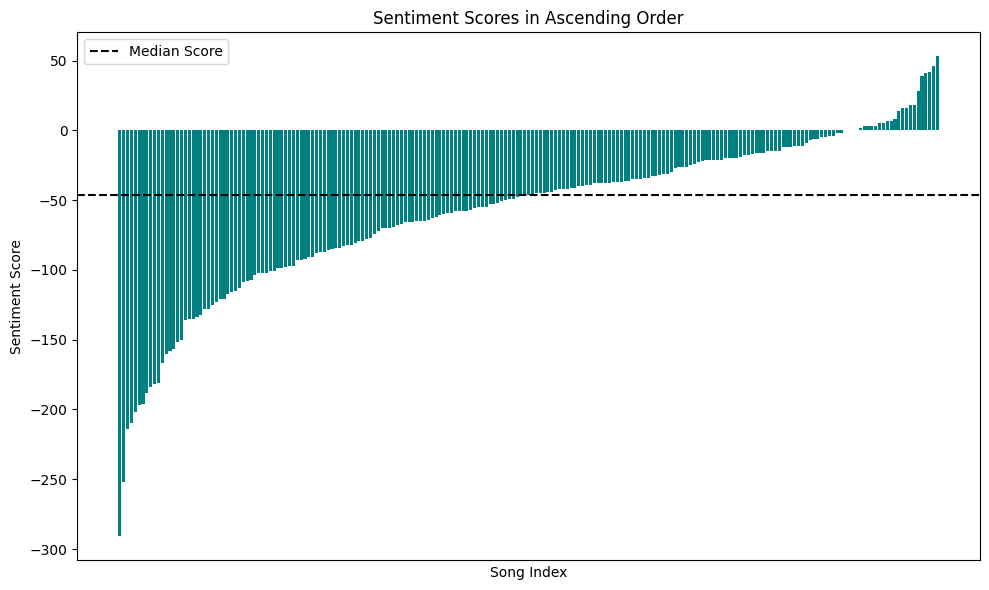

In [ ]:
# Sort the sentiment scores in ascending order
sorted_scores = df['SentimentScore'].sort_values()

# Calculate the median sentiment score
median_score = np.median(sorted_scores)

# Define custom colors for the bars
bar_colors = ['teal']

# Create a bar chart with custom colors
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_scores)), sorted_scores, color=bar_colors)
plt.xlabel('Song Index')
plt.ylabel('Sentiment Score')
plt.title('Sentiment Scores in Ascending Order')

# Add the median score to the plot
plt.axhline(median_score, color='black', linestyle='--', label='Median Score')
plt.legend()

plt.xticks([])  # Remove x-axis tick labels
plt.tight_layout()
plt.show()

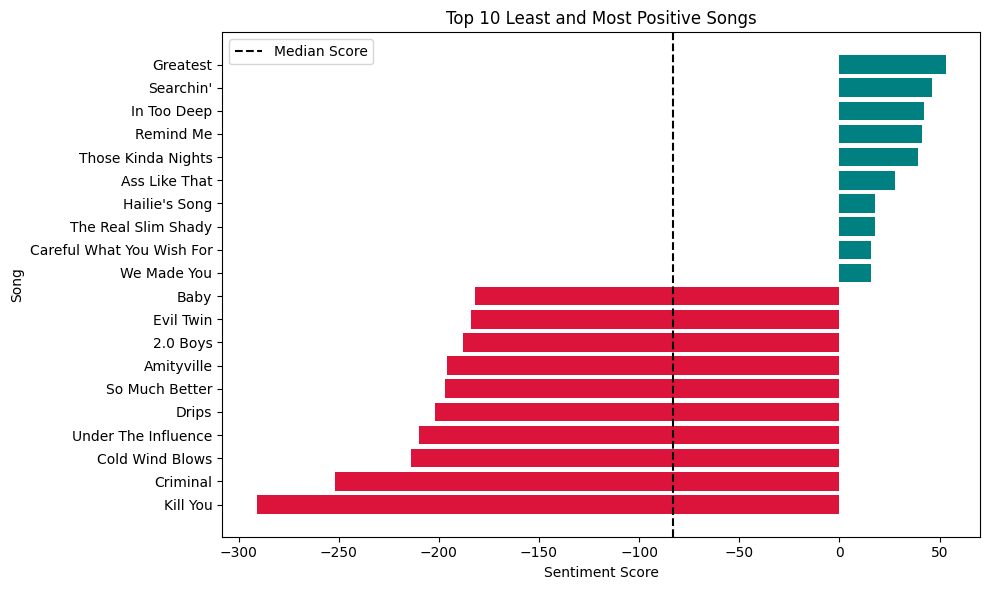

In [ ]:
# Calculate the mean sentiment scores for each song
song_sentiment = df.groupby('Title')['SentimentScore'].mean()

# Sort the sentiment scores in ascending order
sorted_sentiment = song_sentiment.sort_values()

# Select the 10 least and 10 most positive songs
least_positive = sorted_sentiment.head(10)
most_positive = sorted_sentiment.tail(10)

# Concatenate the least and most positive series
top_songs = pd.concat([least_positive, most_positive])

# Calculate the median sentiment score
median_sentiment = top_songs.median()

# Define custom colors for the bars
bar_colors = ['crimson' if score < 0 else 'teal' for score in top_songs]

# Create a bar chart with custom colors
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_songs)), top_songs, color=bar_colors)  # Use barh for horizontal bars

# Add the median line and update the plot title
plt.axvline(x=median_sentiment, color='black', linestyle='--', label='Median Score')
plt.title('Top 10 Least and Most Positive Songs')
plt.legend()

plt.ylabel('Song')
plt.xlabel('Sentiment Score')
plt.yticks(range(len(top_songs)), top_songs.index)  # Set y-axis tick labels
plt.tight_layout()
plt.show()
